# What is the contribution of the tropics to the EEI Trend in the past 20 years?

In [ ]:
import sys
import os
sys.path.append('/work/mh0731/m301104/transient_partitioning/src/')
import numpy as np
import xarray as xr
import pandas as pd
from scipy import stats
#Packages for ICON data
import easygems.healpix as egh
#Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns


outdir = '/work/mh0731/m301104/transient_partitioning/figures/'

def pointwise_correlation_with_significance(field, reference, alpha=0.05):
    field, reference = xr.align(field, reference, join='inner')
    valid_samples = (field.notnull() & reference.notnull()).sum('time')
    corr = xr.corr(field, reference, dim='time')
    clipped_corr = corr.clip(min=-0.999999, max=0.999999)
    dof = valid_samples - 2
    t_stat = clipped_corr * np.sqrt(dof / (1 - clipped_corr**2))
    p_value = xr.apply_ufunc(
        lambda t_value, df: 2 * stats.t.sf(np.abs(t_value), df),
        t_stat,
        dof,
        vectorize=True,
        dask='allowed',
        output_dtypes=[float],
    )
    significance_mask = (p_value < alpha) & (valid_samples >= 3)
    return corr, p_value.where(valid_samples >= 3), significance_mask


def add_significance_hatching(ax, field, significance_mask, hatch='///'):
    ax.contourf(
        field['lon'],
        field['lat'],
        significance_mask.fillna(False).astype(int),
        levels=[0.5, 1.5],
        hatches=[hatch],
        colors='none',
        transform=ccrs.PlateCarree(),
    )
time_slice = slice('2001-01-01','2024-12-31')
ds1 = xr.open_dataset('/work/mh0731/m301104/transient_partitioning/data/CERES_EBAF_Ed4.2.1_Subset_200003-201412.nc').sel(time = time_slice)
ds2 = xr.open_dataset('/work/mh0731/m301104/transient_partitioning/data/CERES_EBAF_Ed4.2.1_Subset_201501-202504.nc').sel(time = time_slice)
CERES = xr.merge([ds1,ds2]).sel(time=time_slice)
GPCP = xr.open_dataset('/work/mh0731/m301104/transient_partitioning/data/GPCP_precip_mon_mean.nc').sel(time=time_slice).rename({'precip':'pr'})
enso = xr.open_dataset('/work/mh0731/m301104/transient_partitioning/data/nina34.anom.nc')
enso = enso.value.resample(time='1YE').mean()#.sel(time=TOA_net_timeseries.time)
ERA_prw = xr.open_dataset('../data/data_stream-moda_stepType-avgua.nc').rename_dims({'valid_time':'time'}).tcwv

datasets = [ds.assign_attrs(grid_name="latlon") for ds in [GPCP, ds1,ds2,CERES, ERA_prw]]
(GPCP, ds1,ds2,CERES, ERA_prw) = datasets

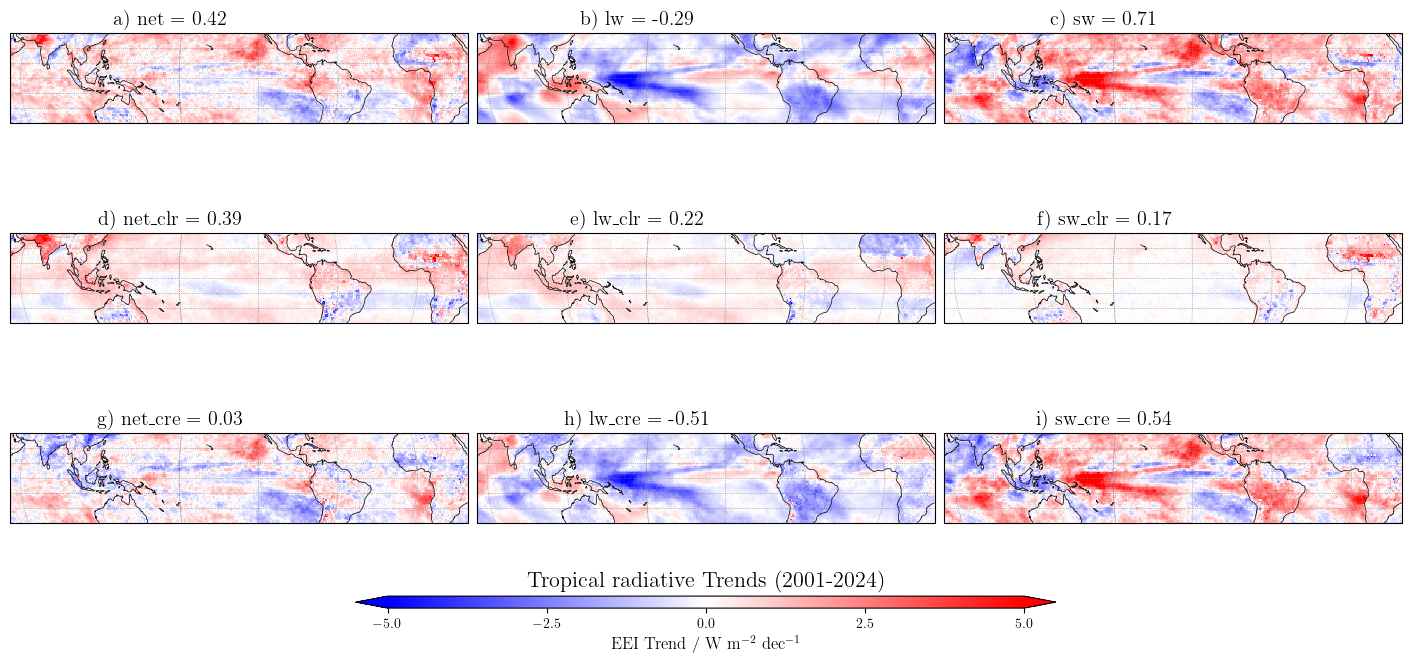

In [ ]:
def lat_mean(ds):
    return ds.weighted(np.cos(np.deg2rad(ds.lat))).mean("lat")

def global_mean(da):
    return lat_mean(da.mean("lon"))
central_lon = -135
color_range_for_trends = 5

def plot_colormesh(ax, da):
    return ax.pcolormesh(da.lon, da.lat, da, vmin=-color_range_for_trends, vmax=color_range_for_trends,
                        cmap="bwr", transform=ccrs.PlateCarree())

def plot_coasts_grid(ax):
    ax.coastlines(lw=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', linestyle=':')

def plot_colorbar(fig, colormap, title, position):
    cbar_ax = fig.add_axes(position)
    return fig.colorbar(colormap, cax=cbar_ax, orientation='horizontal', label=title, extend="both", ticks = np.linspace(-color_range_for_trends,color_range_for_trends,5))

def eei_maps(da, savefile):
    fig,axes = plt.subplots(3, 3, figsize=(14,6), subplot_kw={"projection":ccrs.Robinson(central_longitude=-135)}, constrained_layout=True)
    letter = np.array([["a","b","c"],["d","e","f"],["g","h","i"]])
    for i,vari in enumerate(["","_clr","_cre"]):
        for j,varj in enumerate(["net","lw","sw"]):
            ax = axes[i,j]
    
            t = da[varj+vari].sel(lat=slice(-30,30))
            trend_gm = global_mean(t).values
            cf = plot_colormesh(ax, t)
    
            plot_coasts_grid(ax)
            ax.set_title(letter[i,j]+") "+varj+vari+f" = {trend_gm:0.2f}", position=(0.35, 1.0))
            ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
    
    plot_colorbar(fig, cf, "EEI Trend / W m$^{-2}$ dec$^{-1}$", [0.25, -0.05, 0.5, 0.02])
    plt.title('Tropical radiative Trends (2001-2024)', fontsize=16, y=1.05)
    plt.savefig(savefile, dpi=300, facecolor="w", bbox_inches="tight")
    #fig.tight_layout()


ds_trend = xr.open_mfdataset(["ceres_trends.nc"])
da = ds_trend.sel(season="ANN").load()
eei_maps(da, savefile="eei_trend_maps.png")

## Understanding the shortwave trend

Albedo trend from 

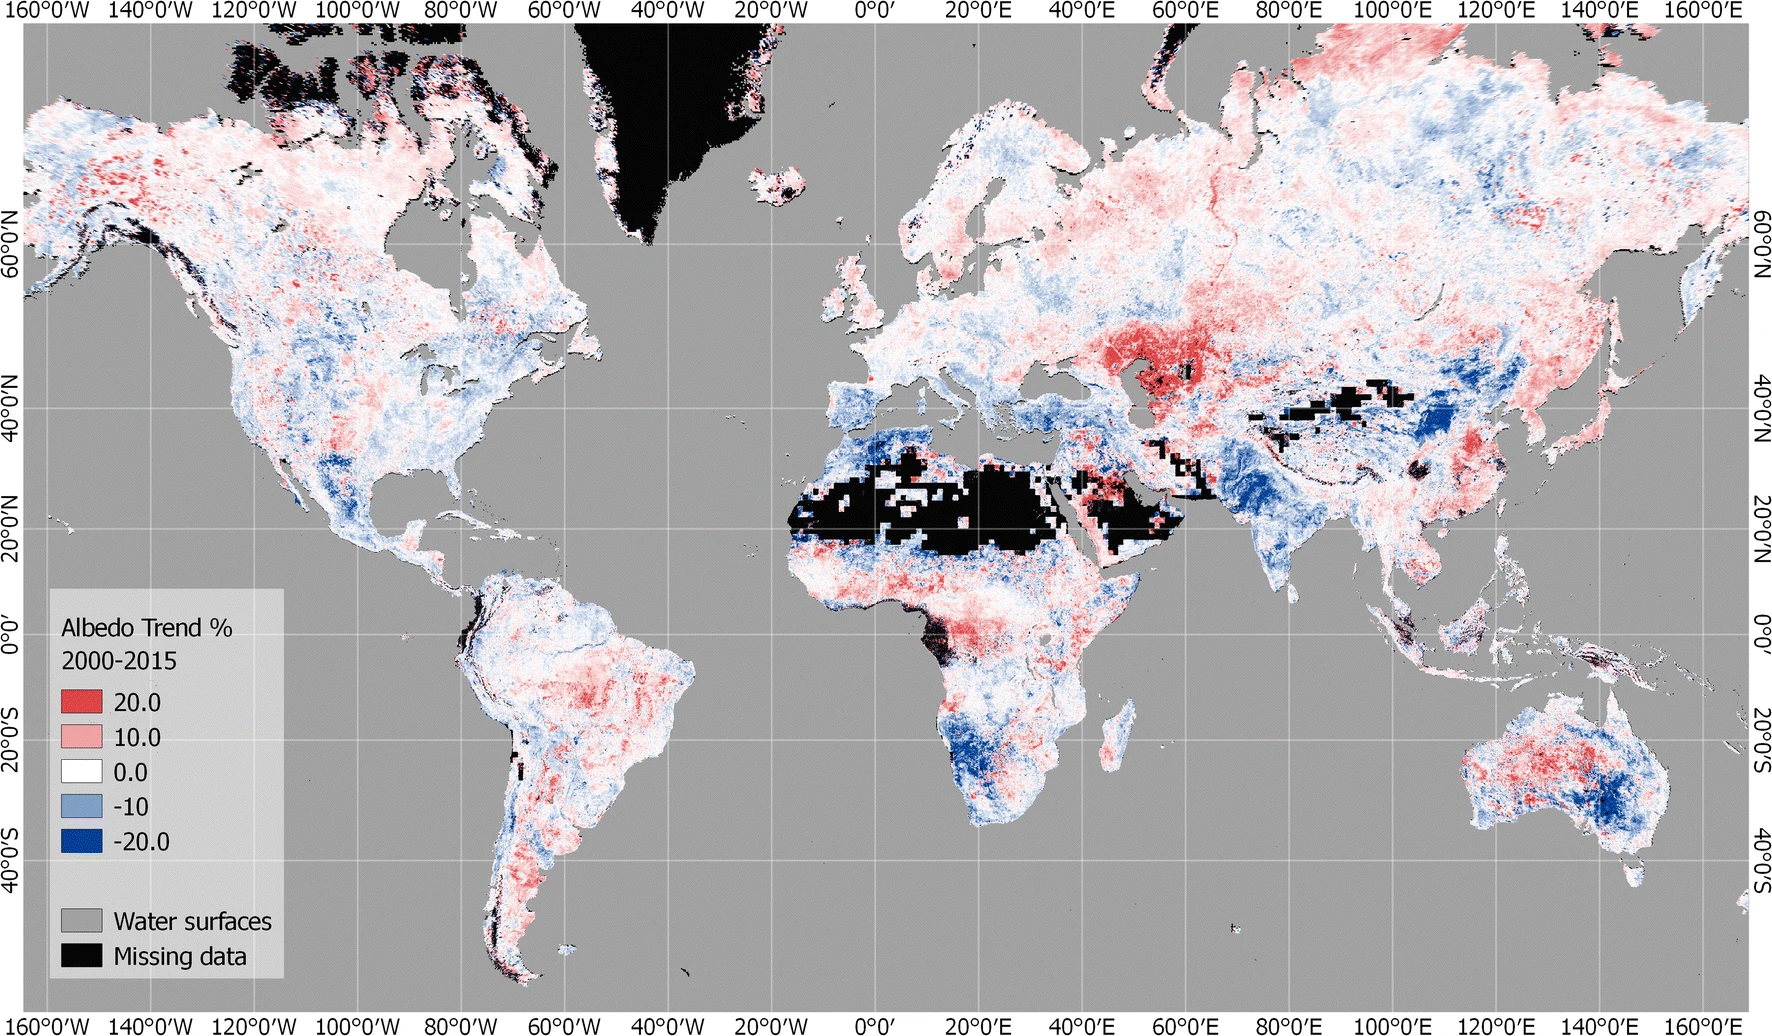

## Calculate albedo Trend from CERES

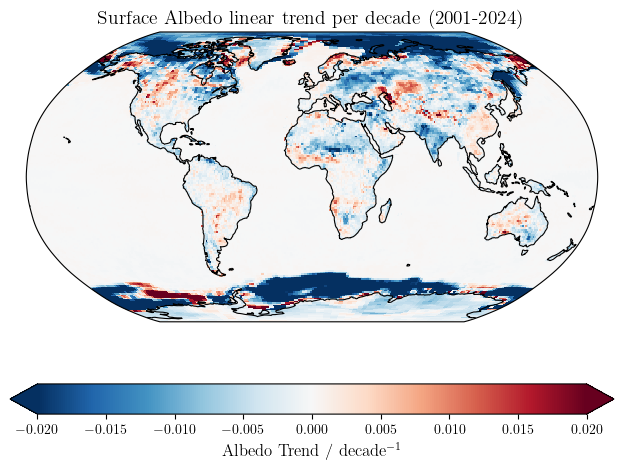

In [10]:
CERES_yr = CERES.resample(time='1YE').mean() #remove seasonal cycle and get interannual trends
albedo_yr = CERES_yr.sfc_sw_up_all_mon / CERES_yr.sfc_sw_down_all_mon

time_years = albedo_yr['time'].dt.year + (albedo_yr['time'].dt.dayofyear - 1) / 365.25
albedo_numeric_time = albedo_yr.assign_coords(time=time_years)

albedo_trend_per_decade = (
    albedo_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
albedo_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-0.02, vmax=0.02,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Albedo Trend / decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_title('Surface Albedo linear trend per decade (2001-2024)', fontsize=14)
plt.tight_layout()

## Plot Shortwave clear sky Trend from CERES

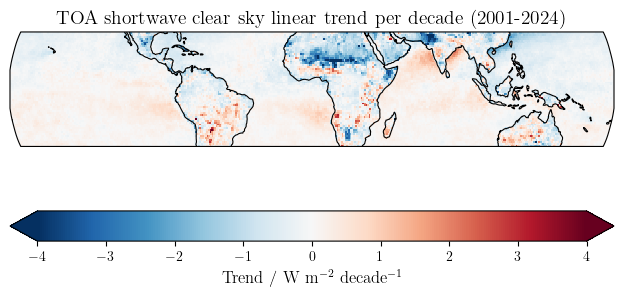

In [ ]:
sw = CERES.toa_sw_clr_c_mon

time_years = sw['time'].dt.year + (sw['time'].dt.dayofyear - 1) / 365.25
sw_numeric_time = sw.assign_coords(time=time_years)

sw_trend_per_decade = (
    sw_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
sw_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-4,vmax=4,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('TOA shortwave clear sky linear trend per decade (2001-2024)', fontsize=14)
plt.tight_layout()

Summary:
- over land, the albedo changes in CERES explain the changes in SW radiation well.
- some region deviate from previously published trends (e.g. Namibia), but overall the trends match reasonably well.
- over ocean there is a low background signal that seems opposite between the hemispheres, apart from the indian ocean (aerosols? Do we care if it cancels?)

# Longwave clear sky feedback

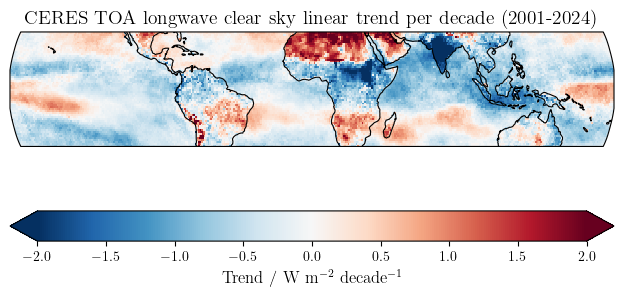

In [3]:
lw = CERES.toa_lw_clr_c_mon

time_years = lw['time'].dt.year + (lw['time'].dt.dayofyear - 1) / 365.25
lw_numeric_time = lw.assign_coords(time=time_years)

lw_trend_per_decade = (
    lw_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
lw_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2,vmax=2,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('CERES TOA longwave clear sky linear trend per decade (2001-2024)', fontsize=14)
plt.tight_layout()

## Approach 1: Explain change using changes in T and RH
Let's have a look at Brett's data:

### Bretts paper is mostly about the LW response parameter, which is not so useful to explain regional trends. However, he also computed a function for OLR as a function of surface temperature and column relative hunmidity:

In [6]:
# Bretts functions
feedback = xr.open_dataset('zenodo_feedback.nc')
olr = xr.open_dataset('zenodo_olr.nc')

#ERA5 data:
era5_skint = xr.open_dataset('../data/ERA5_TS.nc').rename({'valid_time':'time'})
column_rh = xr.open_dataset('../data/ERA5_column_rh.nc')
data = xr.open_dataset('../data/62aab86337d1c3e6116a1f05eb9e5a2a.grib', engine='cfgrib') #relative humidity


def calc_olr(ts_map, rh_map): #interpolate Bretts function
    """
    Calculate outgoing longwave radiation from surface temperature and relative humidity maps.
    
    Parameters
    ----------
    ts_map : xr.DataArray
        Map of surface temperature (K) with any spatial/time dimensions
    rh_map : xr.DataArray
        Map of relative humidity (0-100 or 0-1) with same dimensions as ts_map
        
    Returns
    -------
    olr_map : xr.DataArray
        Map of outgoing longwave radiation (W/m²)
    """
    from scipy.interpolate import interpn
    
    # Ensure inputs are aligned
    ts_map, rh_map = xr.align(ts_map, rh_map, join='override')
    
    # Get the interpolation grid and values
    # olr is structured as (rh, ts) so we need to transpose
    olr_rh = olr.olr.rh.values
    olr_ts = olr.olr.ts.values
    olr_values = olr.olr.values.T  # Transpose from (rh, ts) to (ts, rh)
    
    # Flatten the input arrays for interpolation
    ts_flat = ts_map.values.ravel()
    rh_flat = rh_map.values.ravel()
    
    # Create points array for interpn - must be in same order as grid
    points = np.column_stack([ts_flat, rh_flat])
    
    # Interpolate using interpn
    olr_flat = interpn(
        (olr_ts, olr_rh),  # Grid points in (ts, rh) order
        olr_values,         # Values transposed to (ts, rh) order
        points,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    
    # Reshape back to original shape
    olr_array = olr_flat.reshape(ts_map.shape)
    
    # Restore as DataArray with original coordinates
    olr_map = xr.DataArray(
        olr_array,
        coords=ts_map.coords,
        dims=ts_map.dims,
        name='olr'
    )
    
    return olr_map

/tmp/ipykernel_361728/1799361783.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  column_rh = xr.open_dataset('../data/ERA5_column_rh.nc')
/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [ ]:

# data.to_netcdf('netcdf_file.nc')

#ps = data.isel(isobaricInhPa=slice(9,20)).isobaricInhPa
#column_rh = data.isel(isobaricInhPa=slice(9,20)).weighted(ps).mean('isobaricInhPa')

# ps = data.isel(isobaricInhPa=slice(10,23)).isobaricInhPa
# column_rh = data.isel(isobaricInhPa=slice(10,23)).weighted(ps).mean('isobaricInhPa')

# column_rh.to_netcdf('../data/ERA5_column_rh.nc')

/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [ ]:
df_year = data.isel(time=slice(0,312)).resample(time='1YE').mean()

## Plot ERA5 RH trends at different pressure levels

In [ ]:
# calculate column relative humidity
import numpy as np
import xarray as xr
era5_RH =  xr.open_dataset('../data/62aab86337d1c3e6116a1f05eb9e5a2a.grib', engine='cfgrib') #3d relative humidity
era5_T = xr.open_dataset('../data/e003337d85d043f3fa75bf868290fe68.grib', engine='cfgrib') #3d temperature

T = era5_T.t.isel(isobaricInhPa=slice(0,23))    # K
RH = era5_RH.r.isel(isobaricInhPa=slice(0,23))    # %

# Saturation vapor pressure using Magnus formula
def es(T):
    return xr.apply_ufunc(
        lambda t: 6.1094 * np.exp(17.625 * t / (t + 243.04)),
        T,
        dask='parallelized',
        output_dtypes=[float],
    )

ERA_es = es(T)
dp = -1*era5_RH.isobaricInhPa.diff('isobaricInhPa').isel(isobaricInhPa=slice(0,23))

#calculate column relative humidity
CRHs = []
for t in RH.time: #split in time to make it more memory efficient
    CRH = (RH.sel(time=t)/100*ERA_es.sel(time=t)*dp).sum('isobaricInhPa') / (ERA_es.sel(time=t)*dp).sum('isobaricInhPa')
    CRHs.append(CRH)
# Convert to xarray Dataset
CRH_dataset = xr.concat(CRHs, dim='time')
CRH_dataset = CRH_dataset.assign_coords(time=RH.time)
CRH_dataset.name = 'column_relative_humidity'
CRH_dataset

/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [4]:
# or load the dataset directly
#CRH_dataset.to_netcdf('../data/ERA5_CRH.nc')
CRH = xr.open_dataset('../data/ERA5_CRH.nc').column_relative_humidity

/tmp/ipykernel_361728/264821994.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  CRH = xr.open_dataset('../data/ERA5_CRH.nc').column_relative_humidity


### Now, reconstruct the OLR for each gridpoint and time, calculate the pointwise trend and compare to the CERES trend:

In [7]:
olr_recon = calc_olr(era5_skint.isel(time=slice(0,312)).resample(time='1YE').mean().skt, column_rh.r.isel(time=slice(0,312)).resample(time='1YE').mean()/100)
#olr_recon = calc_olr(era5_skint.isel(time=slice(0,312)).mean('time').skt, df_year.r/100)

In [8]:
olr_recon = calc_olr(era5_skint.isel(time=slice(0,312)).resample(time='1YE').mean().skt, CRH.isel(time=slice(0,312)).resample(time='1YE').mean())

/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


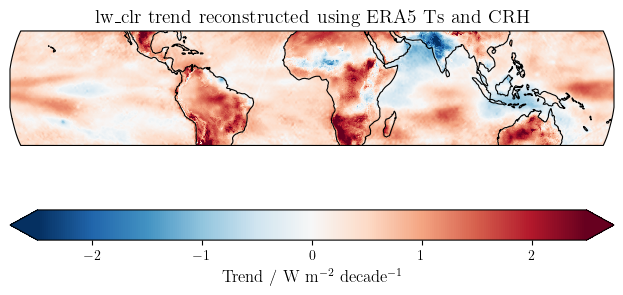

In [11]:
df_year = olr_recon#df.resample(time='1YE').mean()
time_years = df_year['time'].dt.year + (df_year['time'].dt.dayofyear - 1) / 365.25
olr_numeric_time = df_year.assign_coords(time=time_years)

olr_trend_per_decade = (
    olr_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
olr_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    norm = mpl.colors.CenteredNorm(vcenter=0,halfrange=2.5),
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('lw_clr trend reconstructed using ERA5 Ts and CRH', fontsize=14)
plt.tight_layout()

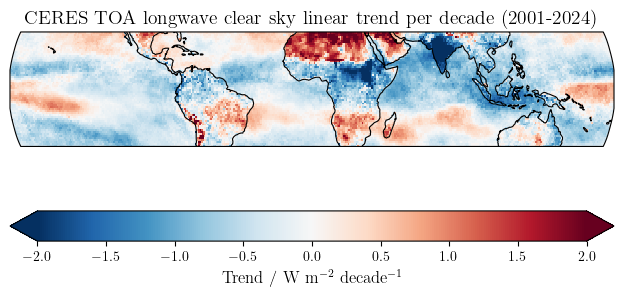

In [12]:
lw = CERES.toa_lw_clr_c_mon

time_years = lw['time'].dt.year + (lw['time'].dt.dayofyear - 1) / 365.25
lw_numeric_time = lw.assign_coords(time=time_years)

lw_trend_per_decade = (
    lw_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
lw_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2,vmax=2,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('CERES TOA longwave clear sky linear trend per decade (2001-2024)', fontsize=14)
plt.tight_layout()

### Comparison:
Some broad patterns agree. There ssems to be a general offset with too high OLRs in the reconstruction, that could come from not considering CO2 yet. Also, over central Africa the reconstruction is opposite to the observed negative OLR trend.

This could tell us that looking at the column relative humidity is not enough, but that it matters where the moisture is located.

So, let's first have a look at the moisture trends at different pressure levels:

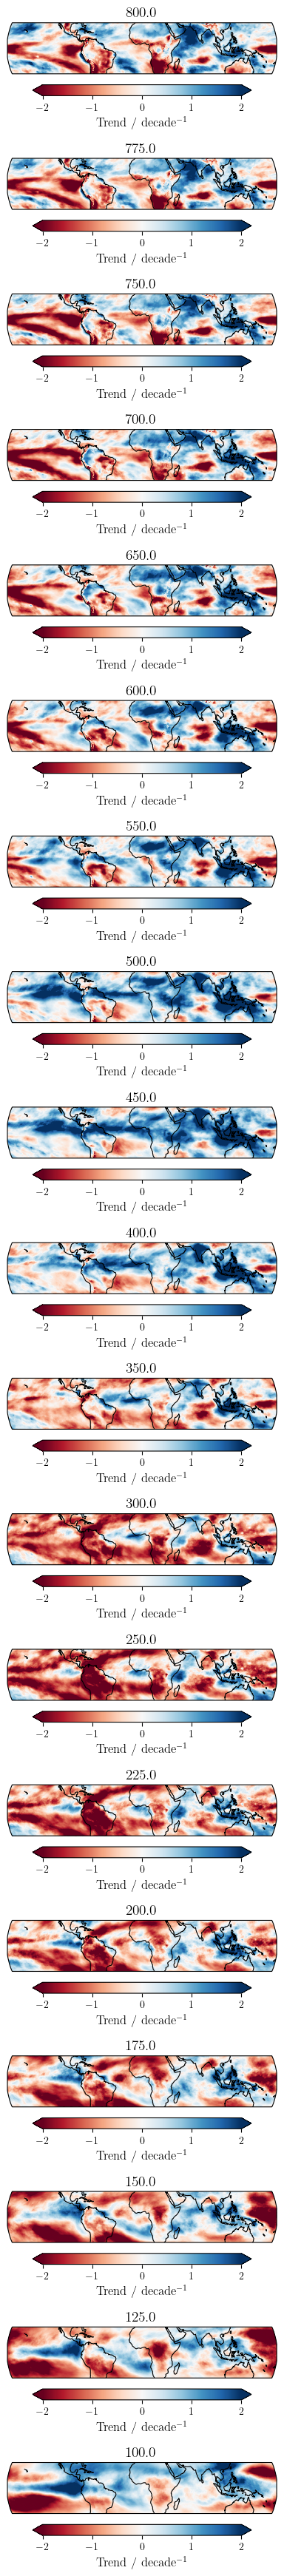

In [4]:
# df_year = data.isel(time=slice(0,312)).resample(time='1YE').mean()
# time_years = df_year['time'].dt.year + (df_year['time'].dt.dayofyear - 1) / 365.25
# df_year = df_year.assign_coords(time=time_years)

fig, ax = plt.subplots(19,1,figsize=(10, 35),subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
for i,level in enumerate(data.isobaricInhPa.isel(isobaricInhPa=slice(8,27))):
    df_year = data.sel(isobaricInhPa=level).isel(time=slice(0,312)).resample(time='1YE').mean()
    time_years = df_year['time'].dt.year + (df_year['time'].dt.dayofyear - 1) / 365.25
    df_year = df_year.assign_coords(time=time_years)
    column_rh_numeric_time = df_year
    column_rh_trend_per_decade = (
    column_rh_numeric_time.polyfit(dim='time', deg=1, skipna=True).r_polyfit_coefficients.sel(degree=1) * 10
    )

    
    column_rh_trend_per_decade.plot(
    ax=ax[i],
    transform=ccrs.PlateCarree(),
    cmap='RdBu',
    vmin=-2,vmax=2,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / decade$^{-1}$'}
    )
    ax[i].add_feature(cf.COASTLINE, linewidth=0.8)
    ax[i].set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
    ax[i].set_title(level.values, fontsize=14)
    del column_rh_numeric_time,df_year
plt.tight_layout()

The humidity trend between 550hPa and 400hPa matches the closest with the observed lw clr trend. This could be the case because those are the regions with the strongest emissions to space.

edit: These fields are biased because I look at them in pressure space. I should remap to temparature space to account for shifts of emission temperature to different pressure levels. THis is due to the effect sketched in the following figure:

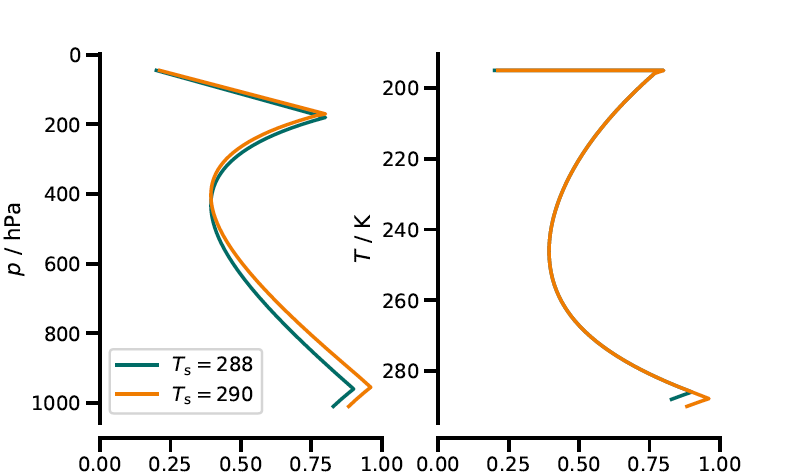

If we select the subsample of 550-350hPa, we get a better fit of the trends:

In [ ]:
sublevels = [550.,500.,450.,400.,350.]
data.sel(isobaricInhPa=sublevels)
ERA_es = es(T).sel(isobaricInhPa=sublevels)
dp = -1*era5_RH.isobaricInhPa.diff('isobaricInhPa').sel(isobaricInhPa=sublevels)

#calculate column relative humidity
CRH_subsample = (RH/100*ERA_es*dp).sum('isobaricInhPa') / (ERA_es*dp).sum('isobaricInhPa')


/home/m/m301104/.conda/envs/easy/lib/python3.12/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


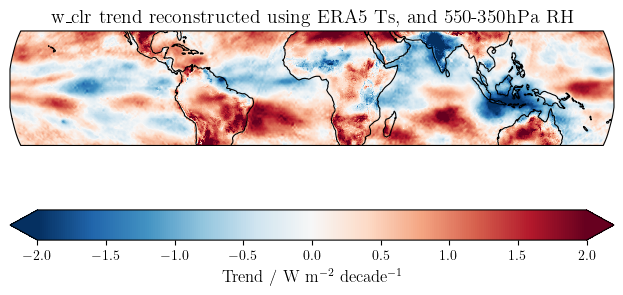

In [29]:
#rh_mid_tropo = data.sel(isobaricInhPa=level).isel(time=slice(0,312)).resample(time='1YE').mean()
df_year = calc_olr(era5_skint.isel(time=slice(0,312)).resample(time='1YE').mean().skt, RH_sub.isel(time=slice(0,312)).resample(time='1YE').mean())
time_years = df_year['time'].dt.year + (df_year['time'].dt.dayofyear - 1) / 365.25
olr_numeric_time = df_year.assign_coords(time=time_years)

olr_trend_per_decade = (
    olr_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
olr_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    norm = mpl.colors.CenteredNorm(vcenter=0,halfrange=2.),
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('w_clr trend reconstructed using ERA5 Ts, and 550-350hPa RH', fontsize=14)
plt.tight_layout()

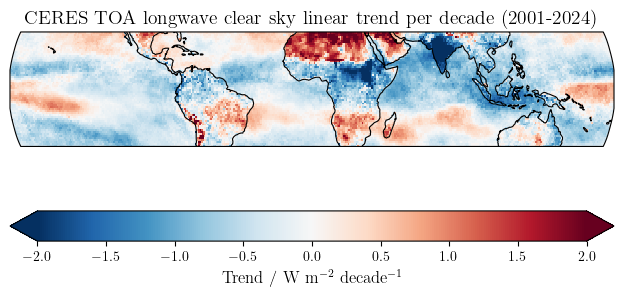

In [19]:
lw = CERES.toa_lw_clr_c_mon

time_years = lw['time'].dt.year + (lw['time'].dt.dayofyear - 1) / 365.25
lw_numeric_time = lw.assign_coords(time=time_years)

lw_trend_per_decade = (
    lw_numeric_time.polyfit(dim='time', deg=1, skipna=True)
    .polyfit_coefficients.sel(degree=1) * 10
)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0)})
lw_trend_per_decade.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2,vmax=2,
    cbar_kwargs={'orientation': 'horizontal', 'label': r'Trend / W m$^{-2}$ decade$^{-1}$'}
)
ax.add_feature(cf.COASTLINE, linewidth=0.8)
ax.set_extent([-180, 180, -30, 30], ccrs.PlateCarree())
ax.set_title('CERES TOA longwave clear sky linear trend per decade (2001-2024)', fontsize=14)
plt.tight_layout()

Conclusion:
- CO2 is still missing. This leads to a too high OLR. COuld be added "analyticall", but WV masking has to be considered
- Patterns become better using only mid-troposheric RH (instead of CRH), which points to their importance
- patterns over ocean agree pretty well, if one consideres the uniform CO2 offset
- THe fact that the RH change at different levels seems to play a role suggests that the usage of an actual radiative transfer model is desirable to recreate the OLR. This also eases the implementation of CO2, and facilitates a well-founded comparison of the different radiative drivers.